# Goodreads EDA — Fantasy & Paranormal

Complete Senior Data Scientist level EDA for the Fantasy & Paranormal category. Explores nested structures (`authors`, `popular_shelves`, `series`), joins books with interactions, and delivers genre-specific insights.

Does not depend on `process_goodreads` or a previous CLI.

In [ ]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BOOK_NUMERIC_COLUMNS, CATEGORIES
from src.utils.io import read_jsonl_sample
from src.utils.cleaning import clean_interactions, _shelves_summary
from src.utils.eda import (
    build_eda_profile,
    author_profile,
    shelves_profile,
    series_profile,
    engagement_profile,
    reading_duration_profile,
    user_rating_behavior,
    platform_growth_profile,
)

sns.set_theme(style='whitegrid')

## 1. Inputs and Loading

Controlled samples are loaded from the raw `.json.gz` files. The cleaning will be performed later, once the data issues are identified and justified.

In [2]:
CATEGORY = 'fantasy_paranormal'
cfg = CATEGORIES[CATEGORY]
BOOKS_SAMPLE = 50_000
INTERACTIONS_SAMPLE = 250_000

print(cfg.books_file)
print(cfg.interactions_file)

/home/chris/Documentos/u/BigBook/data/raw/goodreads_books_fantasy_paranormal.json.gz
/home/chris/Documentos/u/BigBook/data/raw/goodreads_interactions_fantasy_paranormal.json.gz


In [3]:
books_raw = read_jsonl_sample(cfg.books_file, nrows=BOOKS_SAMPLE)
interactions_raw = read_jsonl_sample(cfg.interactions_file, nrows=INTERACTIONS_SAMPLE)

print(f'books_raw:         {books_raw.shape}')
print(f'interactions_raw:  {interactions_raw.shape}')

books_raw:         (50000, 29)
interactions_raw:  (250000, 10)


## 2. General Profiling

Schema, nulls, duplicates, numerical profiles, outliers, categoricals, ratings, and temporality are calculated.

In [4]:
artifacts, summary = build_eda_profile(
    books_raw=books_raw,
    interactions_raw=interactions_raw,
    book_numeric_columns=BOOK_NUMERIC_COLUMNS,
    interaction_numeric_columns=['rating'],
)
summary

,metric,value
0,books_raw_rows,50000.000000
1,interactions_raw_rows,250000.000000
2,books_clean_rows,50000.000000
3,interactions_clean_rows,250000.000000
4,books_columns,29.000000
5,interactions_columns,10.000000
6,explicit_rating_pct,0.481204


## 3. Schema and Nulls

Nested fields (`authors`, `popular_shelves`, `series`) appear as `object` and require explicit flattening.

In [5]:
display(artifacts['books_schema'])
display(artifacts['interactions_schema'])
display(artifacts['books_missing'].head(20))
display(artifacts['interactions_missing'].head(20))

,column,dtype,non_null,nulls,unique
0,asin,str,50000,0,13720
1,authors,object,50000,0,23428
2,average_rating,str,50000,0,293
3,book_id,str,50000,0,50000
4,country_code,str,50000,0,1
5,description,str,50000,0,42995
6,edition_information,str,50000,0,1726
7,format,str,50000,0,140
8,image_url,str,50000,0,33245
9,is_ebook,str,50000,0,2


,column,dtype,non_null,nulls,unique
0,book_id,str,250000,0,54682
1,date_added,str,250000,0,243947
2,date_updated,str,250000,0,243093
3,is_read,bool,250000,0,2
4,rating,int64,250000,0,6
5,read_at,str,250000,0,35241
6,review_id,str,250000,0,250000
7,review_text_incomplete,str,250000,0,15232
8,started_at,str,250000,0,23247
9,user_id,str,250000,0,2112


,column,dtype,missing,empty_strings,missing_pct
0,edition_information,str,0,44873,0.0
1,asin,str,0,36281,0.0
2,kindle_asin,str,0,25779,0.0
3,isbn,str,0,24974,0.0
4,isbn13,str,0,19308,0.0
5,publication_day,str,0,18906,0.0
6,publication_month,str,0,15886,0.0
7,num_pages,str,0,15821,0.0
8,publisher,str,0,14111,0.0
9,language_code,str,0,13670,0.0


,column,dtype,missing,empty_strings,missing_pct
0,review_text_incomplete,str,0,234513,0.0
1,started_at,str,0,207915,0.0
2,read_at,str,0,195146,0.0
3,user_id,str,0,0,0.0
4,book_id,str,0,0,0.0
5,review_id,str,0,0,0.0
6,is_read,bool,0,0,0.0
7,rating,int64,0,0,0.0
8,date_added,str,0,0,0.0
9,date_updated,str,0,0,0.0


In [6]:
# Diagnostic: real nulls vs empty strings in RAW data
def missing_with_empty_strings(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    out = pd.DataFrame({
        'nulls_raw': df.isna().sum(),
        'empty_strings_raw': df.astype('string').eq('').sum(),
    })
    out['missing_effective'] = out['nulls_raw'] + out['empty_strings_raw']
    out['missing_effective_pct'] = (out['missing_effective'] / len(df)).round(4)
    return out.sort_values(['missing_effective', 'nulls_raw'], ascending=False).head(top_n)

print('=== Books: nulls vs empty strings (RAW) ===')
display(missing_with_empty_strings(books_raw, top_n=20))

print('\n=== Interactions: nulls vs empty strings (RAW) ===')
display(missing_with_empty_strings(interactions_raw, top_n=20))

=== Books: nulls vs empty strings (RAW) ===


,nulls_raw,empty_strings_raw,missing_effective,missing_effective_pct
edition_information,0,44873,44873,0.8975
asin,0,36281,36281,0.7256
kindle_asin,0,25779,25779,0.5156
isbn,0,24974,24974,0.4995
isbn13,0,19308,19308,0.3862
publication_day,0,18906,18906,0.3781
publication_month,0,15886,15886,0.3177
num_pages,0,15821,15821,0.3164
publisher,0,14111,14111,0.2822
language_code,0,13670,13670,0.2734



=== Interactions: nulls vs empty strings (RAW) ===


,nulls_raw,empty_strings_raw,missing_effective,missing_effective_pct
review_text_incomplete,0,234513,234513,0.9381
started_at,0,207915,207915,0.8317
read_at,0,195146,195146,0.7806
user_id,0,0,0,0.0
book_id,0,0,0,0.0
review_id,0,0,0,0.0
is_read,0,0,0,0.0
rating,0,0,0,0.0
date_added,0,0,0,0.0
date_updated,0,0,0,0.0


## 4. Author Analysis

`authors` is a list of `{author_id, role}` objects. Each book can have multiple entries: main authors, translators, illustrators. If `primary_author_id` is used as a feature without filtering the role, translators contaminate the author signal.

In [7]:
author_artifacts = author_profile(books_raw)
display(author_artifacts['author_count_dist'])
display(author_artifacts['role_dist'])

,author_count_bin,books,pct
0,1,39335,0.78670
1,2,7923,0.15846
2,3,1426,0.02852
3,4,394,0.00788
4,5,148,0.00296
5,6,107,0.00214
6,7,46,0.00092
7,8,54,0.00108
8,9,52,0.00104
9,10,66,0.00132


,role,books,pct
0,<blank>,48987,0.97974
1,Editor,598,0.01196
2,editor,36,0.00072
3,Pseudonym,36,0.00072
4,Editor / Contributor,25,0.00050
...,...,...,...
98,Compiler,1,0.00002
99,Seleccion,1,0.00002
100,Editor/Introduction,1,0.00002
101,writer,1,0.00002


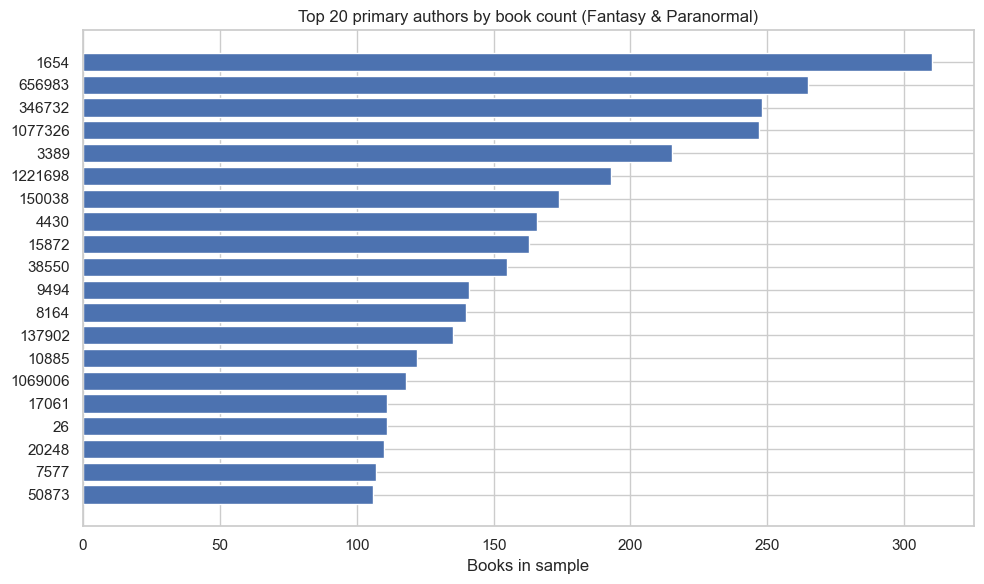


Unique authors (primary_author_id): 16600
Books without identified author:       0


In [8]:
top_authors = author_artifacts['top_authors'].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_authors['author_id'].astype(str)[::-1], top_authors['book_count'][::-1])
ax.set_xlabel('Books in sample')
ax.set_title('Top 20 primary authors by book count (Fantasy & Paranormal)')
plt.tight_layout()
plt.show()

print(f"\nUnique authors (primary_author_id): {author_artifacts['top_authors']['author_id'].nunique()}")
print(f"Books without identified author:       {author_artifacts['author_count_dist'].set_index('author_count_bin').loc['0', 'books'] if '0' in author_artifacts['author_count_dist']['author_count_bin'].values else 0}")

## 5. Popular Shelves / Genre Analysis

`popular_shelves` is user taxonomy: each book has a list of `{name, count}` representing how many users placed the book on that shelf. It contains both genre signals (`fantasy`, `paranormal`, `urban-fantasy`) and reading status signals (`to-read`, `currently-reading`, `read`). The `to-read` field is a proxy for demand/hype, not genre.

In [9]:
shelf_artifacts = shelves_profile(books_raw, top_n=30)

print('=== Distribución de shelf_count por libro ===')
display(shelf_artifacts['shelf_count_dist'].head(15))

print('\n=== to-read como indicador de demanda ===')
display(shelf_artifacts['to_read_dist'])

=== Distribución de shelf_count por libro ===


,shelf_count,books,pct
0,1,2,0.00004
1,2,3,0.00006
2,3,24,0.00048
3,4,59,0.00118
4,5,74,0.00148
5,6,114,0.00228
6,7,136,0.00272
7,8,166,0.00332
8,9,186,0.00372
9,10,236,0.00472



=== to-read como indicador de demanda ===


,stat,value
0,count,49647.000000
1,mean,6202.335891
2,std,30151.319313
3,min,1.000000
4,25%,76.000000
5,50%,388.000000
6,75%,1951.500000
7,90%,8952.800000
8,95%,21515.000000
9,99%,129905.000000


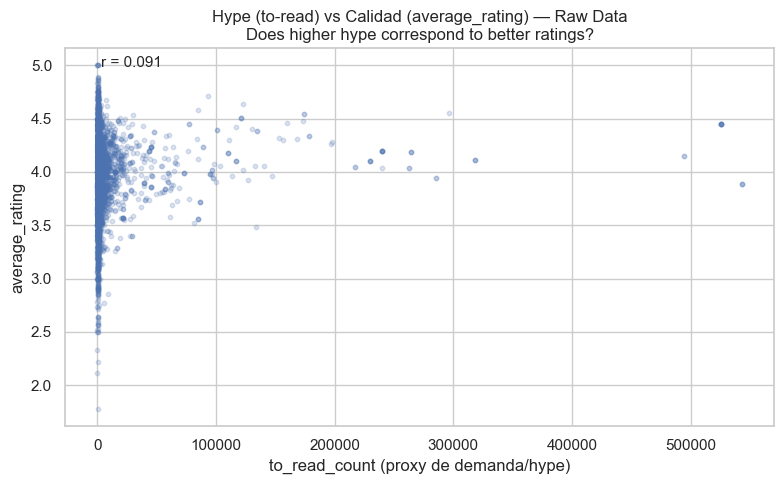

In [10]:
# Extracting to-read count from raw nested data to examine proxy for demand
to_read_data = books_raw['popular_shelves'].map(lambda s: _shelves_summary(s, top_n=20)).apply(pd.Series)
books_raw['to_read_count'] = to_read_data['to_read_count'].values
books_raw['average_rating_numeric'] = pd.to_numeric(books_raw['average_rating'], errors='coerce')

sample_raw = books_raw[['to_read_count', 'average_rating_numeric']].dropna().sample(min(5000, len(books_raw)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample_raw['to_read_count'], sample_raw['average_rating_numeric'], alpha=0.2, s=10)
ax.set_xlabel('to_read_count (proxy de demanda/hype)')
ax.set_ylabel('average_rating')
ax.set_title('Hype (to-read) vs Calidad (average_rating) — Raw Data\nDoes higher hype correspond to better ratings?')
corr = sample_raw[['to_read_count', 'average_rating_numeric']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
print('\n=== Top 20 co-ocurrencias de shelves (pares de géneros más frecuentes) ===')
display(shelf_artifacts['cooccurrence_sample'].head(20))


=== Top 20 co-ocurrencias de shelves (pares de géneros más frecuentes) ===


,shelf_a,shelf_b,book_count
0,fantasy,to-read,42977
1,currently-reading,to-read,40923
2,currently-reading,fantasy,36638
3,fiction,to-read,29791
4,fantasy,fiction,28767
5,favorites,to-read,28667
6,owned,to-read,28502
7,fantasy,favorites,27551
8,fantasy,owned,26870
9,currently-reading,fiction,26709


## 6. Series Analysis

Fantasy is the genre with the highest rate of books in series. The `series` field contains IDs of series to which the book belongs. Books in series tend to have more ratings (the reader is already committed to the saga) and exhibit survivorship bias: nobody continues a bad series.

In [12]:
series_artifacts = series_profile(books_raw)

# This profiling of series data is done before cleaning to justify the need for flattening the nested structures
display(series_artifacts['standalone_vs_series'])
display(series_artifacts['series_length_dist'])

s = series_artifacts['summary']
print(f"\n{s['pct_in_series']:.1%} of books in sample belong to at least one series")
print(f"Median series length (for books in series): {s['median_length']:.1f} series IDs")

,group,books,pct
0,standalone,13770,0.2754
1,in_series,36230,0.7246


,series_count,books,pct
0,0,13770,0.27540
1,1,31883,0.63766
2,2,3289,0.06578
3,3,674,0.01348
4,4,384,0.00768



72.5% of books in sample belong to at least one series
Median series length (for books in series): 1.0 series IDs


In [13]:
import numpy as np

# Identifying patterns in Series ratings vs Standalone ratings (using raw data with numeric conversion)
books_raw['series_count_num'] = books_raw['series'].apply(lambda x: len(x) if isinstance(x, list) else 0)
books_raw['in_series'] = books_raw['series_count_num'].gt(0)
books_raw['average_rating_numeric'] = pd.to_numeric(books_raw['average_rating'], errors='coerce')

# Quick rating comparison by book type in raw data
series_rating_raw = books_raw.groupby('in_series')['average_rating_numeric'].describe()[['count','mean','50%','std']]
print('Rating by book type (Raw Data):')
display(series_rating_raw)

Rating by book type (Raw Data):


,count,mean,50%,std
in_series,,,,
False,13770.0,3.822272,3.84,0.422465
True,36230.0,3.988576,4.00,0.325970


## 7. Ratings

`average_rating` at the book level and `rating` at the interaction level are analyzed. `rating = 0` is the Goodreads convention for absence of explicit rating: the user added the book without rating it.

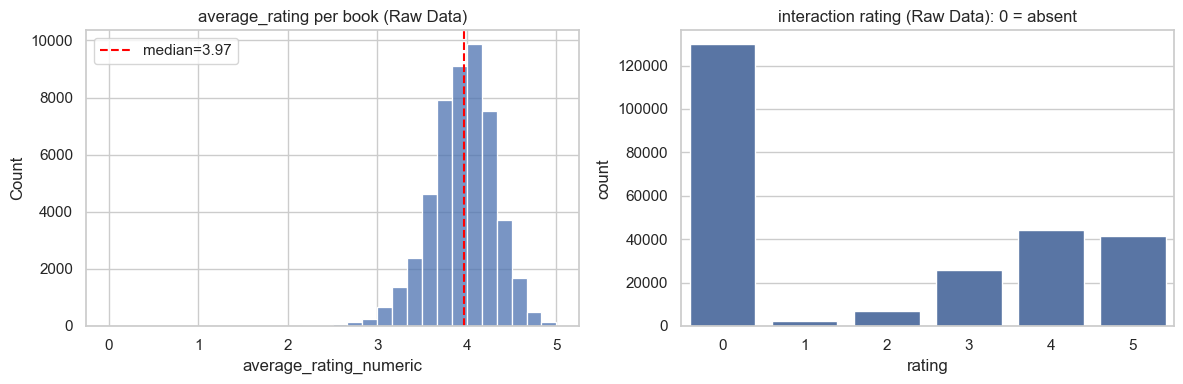

In [14]:
# Exploring raw rating distributions
interactions_raw['rating_numeric'] = pd.to_numeric(interactions_raw['rating'], errors='coerce')
books_raw['average_rating_numeric'] = pd.to_numeric(books_raw['average_rating'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(books_raw['average_rating_numeric'].dropna(), bins=30, ax=axes[0])
axes[0].set_title('average_rating per book (Raw Data)')
axes[0].axvline(books_raw['average_rating_numeric'].median(), color='red', linestyle='--', label=f"median={books_raw['average_rating_numeric'].median():.2f}")
axes[0].legend()

sns.countplot(data=interactions_raw, x='rating', ax=axes[1])
axes[1].set_title('interaction rating (Raw Data): 0 = absent')
plt.tight_layout()
plt.show()

## 8. User Behavior in Interactions

Interactions are not homogeneous: many users only add books to their shelf without reading them, others read without rating. This section quantifies these patterns and analyzes how long it takes to read a book.

In [15]:
# Temporary cleaning to profile duration accurately
interactions_temp = clean_interactions(interactions_raw)

duration_artifacts = reading_duration_profile(interactions_temp)

print(f"Interactions with duration data in sample: {duration_artifacts['pct_with_duration']:.1%}")
print(f"(requires both started_at and read_at present)")
display(duration_artifacts['duration_stats'])

Interactions with duration data in sample: 14.9%
(requires both started_at and read_at present)


,stat,value
0,count,37250.000000
1,mean,13.848671
2,std,35.908535
3,min,0.000000
4,25%,1.000000
5,50%,3.000000
6,75%,10.000000
7,90%,29.000000
8,95%,59.000000
9,99%,210.000000


## 8.1 User Rating Behavior

User rating behavior is analyzed using `interactions_temp` to keep this section inside the diagnostic stage before final cleaning.

In [16]:
user_artifacts = user_rating_behavior(interactions_temp)

print('=== Ratings per user ===')
display(user_artifacts['ratings_per_user'])

print('\n=== User classification (>=3 ratings) ===')
display(user_artifacts['user_type_dist'])

=== Ratings per user ===


,stat,value
0,count,2040.000000
1,mean,58.971078
2,std,89.077065
3,min,1.000000
4,25%,10.000000
5,50%,27.500000
6,75%,70.000000
7,90%,147.000000
8,95%,212.050000
9,99%,461.050000



=== User classification (>=3 ratings) ===


,user_type,users,pct
0,generous,1429,0.754488
1,balanced,413,0.218057
2,strict,52,0.027455


,year,new_interactions,pct_with_rating
0,2006,13,1.000000
1,2007,547,0.926874
2,2008,6467,0.747487
3,2009,4061,0.531150
4,2010,3181,0.607985
5,2011,3383,0.623116
6,2012,69757,0.653483
7,2013,44261,0.440004
8,2014,34090,0.412790
9,2015,31899,0.398602


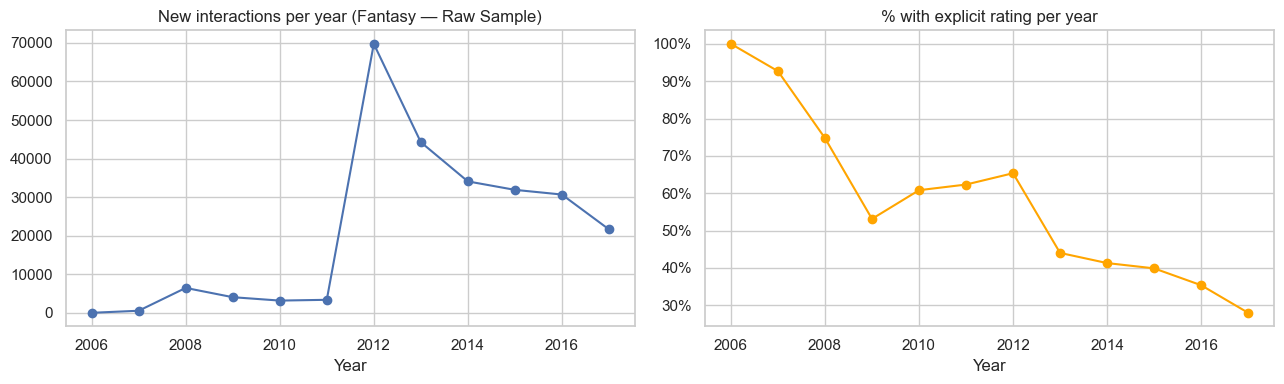

In [17]:
growth = platform_growth_profile(interactions_temp)
display(growth)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
growth.set_index('year')['new_interactions'].plot(ax=axes[0], marker='o')
axes[0].set_title('New interactions per year (Fantasy — Raw Sample)')
axes[0].set_xlabel('Year')

growth.set_index('year')['pct_with_rating'].plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('% with explicit rating per year')
axes[1].set_xlabel('Year')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

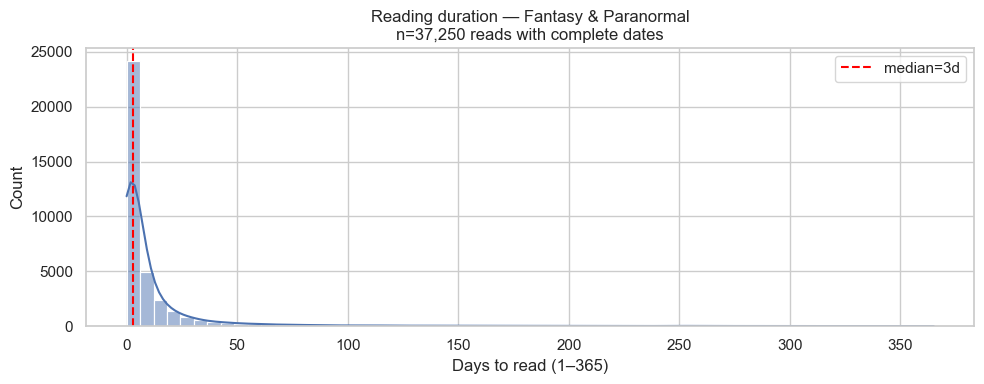

In [18]:
dur = duration_artifacts['duration_distribution']
if len(dur) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(dur, bins=60, ax=ax, kde=True)
    ax.set_xlabel('Days to read (1–365)')
    ax.set_title(f'Reading duration — Fantasy & Paranormal\nn={len(dur):,} reads with complete dates')
    ax.axvline(dur.median(), color='red', linestyle='--', label=f'median={dur.median():.0f}d')
    ax.legend()
    plt.tight_layout()
    plt.show()

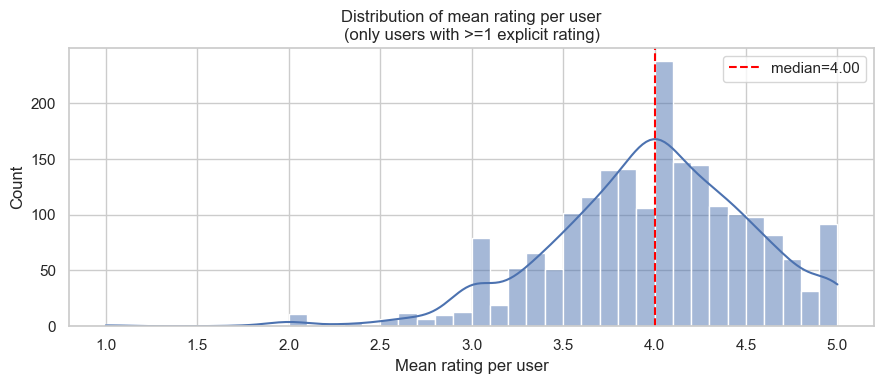

In [19]:
mean_ratings = user_artifacts['mean_rating_per_user']
if len(mean_ratings) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(mean_ratings, bins=40, ax=ax, kde=True)
    ax.set_xlabel('Mean rating per user')
    ax.set_title('Distribution of mean rating per user\n(only users with >=1 explicit rating)')
    ax.axvline(mean_ratings.median(), color='red', linestyle='--', label=f'median={mean_ratings.median():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Book-Level Engagement and Cold-Start

Book-level interaction density is profiled using the raw books sample plus temporally cleaned interactions. This section makes the cold-start problem explicit before any production curation is applied.

In [ ]:
eng_artifacts = engagement_profile(books_raw, interactions_temp)

print('=== Interaction mode mix ===')
display(eng_artifacts['engagement_modes'])

book_ids = books_raw[['book_id']].copy()
book_ids['book_id'] = book_ids['book_id'].astype(str)

book_counts = interactions_temp.groupby('book_id').size().rename('interaction_count').reset_index()
book_counts['book_id'] = book_counts['book_id'].astype(str)

book_engagement = book_ids.merge(book_counts, on='book_id', how='left')
book_engagement['interaction_count'] = book_engagement['interaction_count'].fillna(0).astype(int)

cold_start_stats = pd.DataFrame([
    {'metric': 'books_with_0_interactions', 'books': int(book_engagement['interaction_count'].eq(0).sum()), 'pct': book_engagement['interaction_count'].eq(0).mean()},
    {'metric': 'books_with_lt_1_interaction', 'books': int(book_engagement['interaction_count'].lt(1).sum()), 'pct': book_engagement['interaction_count'].lt(1).mean()},
    {'metric': 'books_with_lt_10_interactions', 'books': int(book_engagement['interaction_count'].lt(10).sum()), 'pct': book_engagement['interaction_count'].lt(10).mean()},
    {'metric': 'books_with_gte_10_interactions', 'books': int(book_engagement['interaction_count'].ge(10).sum()), 'pct': book_engagement['interaction_count'].ge(10).mean()},
])
print('\n=== Cold-start diagnostics by book ===')
display(cold_start_stats)

ra = eng_artifacts['rating_agreement'].dropna()
positive_pop = book_engagement.loc[book_engagement['interaction_count'] > 0, 'interaction_count'].sort_values(ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ra['average_rating'], ra['mean_user_rating'], alpha=0.25, s=8)
axes[0].axline((0, 0), slope=1, color='red', linestyle='--', label='perfect agreement')
axes[0].set_xlabel('books.average_rating (Goodreads global)')
axes[0].set_ylabel('mean(interactions.rating_clean) - sample')
axes[0].set_title('Rating agreement: Goodreads global vs. sample')
if len(ra) > 1:
    r = ra[['average_rating', 'mean_user_rating']].corr().iloc[0, 1]
    axes[0].text(0.05, 0.93, f'r = {r:.3f}\nn = {len(ra):,} books', transform=axes[0].transAxes, fontsize=10)
axes[0].legend()

if len(positive_pop) > 0:
    positive_pop.plot(ax=axes[1], logy=True, logx=True, color='steelblue')
    axes[1].set_title('Popularity by book (log-log) - power law')
    axes[1].set_xlabel('Book Rank')
    axes[1].set_ylabel('interaction_count (log)')
    top20 = positive_pop.iloc[:int(len(positive_pop) * 0.2)].sum() / positive_pop.sum() if len(positive_pop) > 5 else None
    if top20 is not None:
        axes[1].text(0.05, 0.1, f'Top 20% books: {top20:.1%}\nof interactions', transform=axes[1].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 10. Numerics, Correlations, and Outliers

Goodreads metadata has long tails, especially for popularity counts. This section keeps the diagnostics that justify capping or transforming book-level count features in the processing notebook.

In [ ]:
display(artifacts['books_numeric_profile'])
display(artifacts['books_outliers'])

books_numeric = books_raw.copy()
for col in ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages', 'publication_year']:
    if col in books_numeric.columns:
        books_numeric[col] = pd.to_numeric(books_numeric[col], errors='coerce')

num_cols = ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages', 'publication_year']
corr = books_numeric[[c for c in num_cols if c in books_numeric.columns]].corr(numeric_only=True)
display(corr)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, ax=ax)
ax.set_title('Correlations of raw metadata (diagnostic stage)')
plt.tight_layout()
plt.show()

## 11. Duplicates and Cardinality

The duplicate rate is measured before any curation. Duplicate `work_id` is expected because a work can appear in multiple editions.

In [24]:
display(artifacts['duplicates'])

,key,duplicates,records
0,books.book_id,0,50000
1,books.work_id,13430,50000
2,interactions.review_id,0,250000
3,interactions.user_id_book_id,0,250000


## 12. Cleaning Implications

The EDA stops at diagnosis. These findings should be operationalized in `Processing_Curation_Fantasy.ipynb`, not executed here.

1. **Schema and Nulls (Section 3):** Missing values and string-encoded numerics require explicit normalization.
2. **Author Analysis (Section 4):** Nested author fields and non-primary roles can contaminate author features.
3. **Genre/Shelves (Section 5):** `to_read_count` should be extracted separately from genre shelf signals.
4. **Series (Section 6):** Series membership must be flattened into structured features.
5. **Ratings (Section 7):** `rating = 0` represents missing explicit feedback, not a valid low score.
6. **Engagement and Cold-Start (Section 9):** Book-level interaction sparsity should become explicit aggregates such as `interaction_count` and `is_cold_start`.
7. **Numerics and Outliers (Section 10):** Raw popularity counts and `publication_year` need guarded handling in curation.
8. **Duplicates (Section 11):** Edition-level duplication should be handled explicitly when building curated outputs.

## 13. Category Specific Diagnostic Summary: Fantasy & Paranormal

Fantasy is the genre of serialized fiction par excellence. The diagnostic signals most relevant to downstream feature engineering are:
- **High series rate**: the narrative of extended worldbuilding favors long sagas.
- **Well-defined sub-genres**: `urban-fantasy`, `paranormal-romance`, and `young-adult` appear as distinct shelf clusters.
- **Strong administrative intent signals**: `to-read` and shelf-only interactions measure demand more than satisfaction.
- **Role complexity**: translators, editors, and illustrators appear often enough to require role-aware author features.

In [ ]:
ser_s = series_artifacts['summary']
dur_stats = duration_artifacts['duration_stats']
dur_median = dur_stats[dur_stats['stat'] == 'median']['value'].values[0] if len(dur_stats) > 0 else float('nan')

ra_df = eng_artifacts['rating_agreement'].dropna()
rating_corr = ra_df[['average_rating', 'mean_user_rating']].corr().iloc[0, 1] if len(ra_df) > 1 else float('nan')

shelf_only_row = eng_artifacts['engagement_modes'][eng_artifacts['engagement_modes']['mode'] == 'shelf_only']
shelf_only_pct = shelf_only_row['pct'].values[0] if len(shelf_only_row) > 0 else float('nan')

cold_start_row = cold_start_stats[cold_start_stats['metric'] == 'books_with_lt_10_interactions']
cold_start_pct = cold_start_row['pct'].values[0] if len(cold_start_row) > 0 else float('nan')

top_shelf = shelf_artifacts['top_shelf_names']['shelf_name'].iloc[0] if len(shelf_artifacts['top_shelf_names']) > 0 else 'N/A'

print('=== FANTASY & PARANORMAL DIAGNOSTIC SUMMARY ===')
print(f"Books in series:                    {ser_s['pct_in_series']:.1%}")
print(f"Books with <10 interactions:        {cold_start_pct:.1%}")
print(f"Median reading duration:            {dur_median:.0f} days")
print(f"Goodreads/sample rating correlation:{rating_corr:.3f}")
print(f"Shelf-only users:                   {shelf_only_pct:.1%} of interactions")
print(f"Most frequent shelf:                '{top_shelf}'")
print('Hype vs quality signal:             see Section 5 (to-read vs average_rating)')

## 14. Conclusions and Key Insights

Based on the exploratory analysis of the **Fantasy & Paranormal** sample, the following observations are most relevant for the design of curation and recommendation features:

1. **Sagas Dominance (72.5%)**: The majority of books belong to a series, so series-aware features are likely critical for recommendation quality.
2. **Cold-Start Is the Default Regime**: Most books have extremely sparse interaction histories, so the processing pipeline should surface explicit cold-start indicators.
3. **Hype vs. Satisfaction Are Different Signals**: Shelf-only behavior and `to-read` counts capture intent or demand, while explicit ratings capture satisfaction.
4. **Popularity Features Are Heavy-Tailed**: `ratings_count` and `text_reviews_count` need robust treatment before they are used in modeling.
5. **Feature Cleaning Belongs in Processing**: The EDA justifies transformations such as guarded `publication_year`, duplicate handling, and missing-aware rating features, but the canonical execution should stay in the processing notebook.